In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
def create_feature_matrix(x, nb_features):
    tmp_features = []
    for deg in range(1, nb_features + 1):
        tmp_features.append(np.power(x, deg))
    return np.column_stack(tmp_features).astype(np.float32)

In [ ]:
df = pd.read_csv("bottle.csv")
data = df[["Salnty", "T_degC"]].iloc[:700].dropna()
X = data["Salnty"].values.reshape(-1, 1).astype(np.float32)
y = data["T_degC"].values.reshape(-1, 1).astype(np.float32)

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (675, 1)
y shape: (675, 1)


In [ ]:
print(data)

     Salnty  T_degC
0    33.440   10.50
1    33.440   10.46
2    33.437   10.46
3    33.420   10.45
4    33.421   10.45
..      ...     ...
693  33.925    7.42
694  33.930    7.30
695  33.953    6.76
696  34.000    5.90
697  34.020    5.77

[675 rows x 2 columns]


In [ ]:
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
y = (y - np.mean(y, axis=0)) / np.std(y, axis=0)

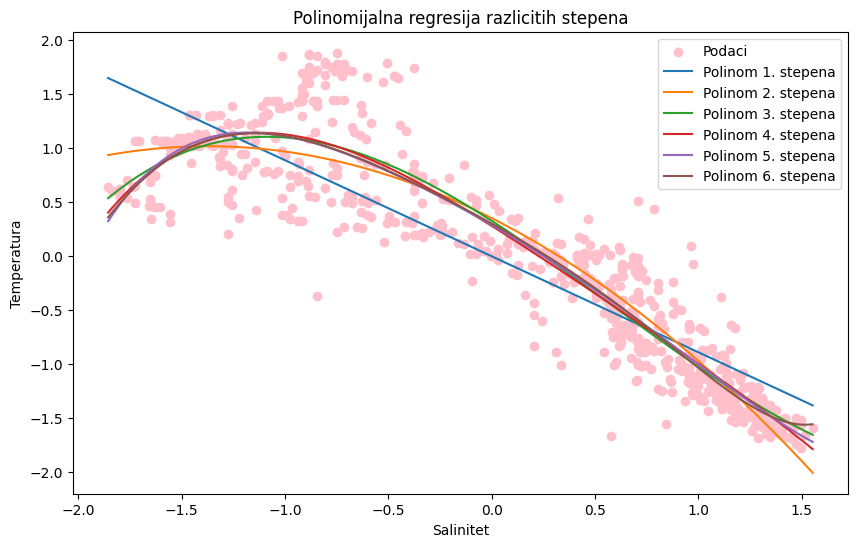

In [12]:
degrees = range(1, 7)
errors = []

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='pink', label='Podaci')

for nb_features in degrees:
    X_poly = create_feature_matrix(X, nb_features)

    w = tf.Variable(tf.zeros((nb_features, 1), dtype=tf.float32))
    b = tf.Variable(0.0, dtype=tf.float32)

    learning_rate = 0.1
    nb_epochs = 100

    adam = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    for epoch in range(nb_epochs):
        with tf.GradientTape() as tape:
            loss_val = tf.reduce_mean(tf.square(tf.add(tf.matmul(X_poly, w), b) - y))
        grads = tape.gradient(loss_val, [w, b])
        adam.apply_gradients(zip(grads, [w, b]))

    errors.append(loss_val.numpy())

    sorted_indices = np.argsort(X.flatten())
    x_sorted = X[sorted_indices]
    X_poly_sorted = create_feature_matrix(x_sorted, nb_features)
    y_pred = tf.add(tf.matmul(X_poly_sorted, w), b).numpy()

    plt.plot(x_sorted, y_pred, label=f'Polinom {nb_features}. stepena')

plt.xlabel("Salinitet")
plt.ylabel("Temperatura")
plt.legend()
plt.title("Polinomijalna regresija razlicitih stepena")
plt.show()

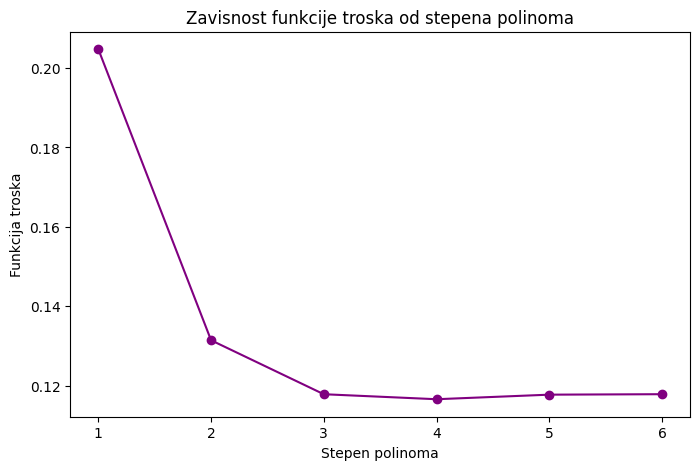

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(degrees, errors, marker='o', linestyle='-', color='purple')
plt.xlabel("Stepen polinoma")
plt.ylabel("Funkcija troska")
plt.title("Zavisnost funkcije troska od stepena polinoma")
plt.show()


Povecanjem stepena polinoma model se sve bolje prilagodjava podacima, ali postoji opasnost od overfitting-a.
Vrednost funkcije troska(MSE) opada sa povecanjem stepena polinoma- smanjuje se greska na trening skupu.
Polinom stepena 3 znacajno poboljsava performanse, a posle njega je pad funkcije troska sporiji.


